# CSC8645 – Task 1: Food Image Segmentation
### Intelligent Food Recognition System using Semantic Segmentation
**Dataset:** FoodSeg103 [1] | **Architecture:** U-Net + ResNet encoder | **Classes:** 104 (background + 103 food categories)

Two models are developed and compared:
- **Baseline** — U-Net + ResNet34, trained from scratch, fixed learning rate
- **Enhanced** — U-Net + ResNet34, ImageNet pre-trained encoder, LR scheduler, data augmentation, best-model checkpointing

---
*References*
- [1] Wu, X., et al. "A large-scale benchmark for food image segmentation." ACM MM 2021. https://dl.acm.org/doi/pdf/10.1145/3474085.3475201
- [2] Ronneberger, O., et al. "U-Net: Convolutional networks for biomedical image segmentation." MICCAI 2015.


## 1. Setup
Installing required libraries.

In [ ]:
!pip install segmentation-models-pytorch -q
!pip install torchsummary -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.6 MB/s eta 0:00:00


## 2. GPU Configuration
Configuring GPU for faster training. `pin_memory`, `num_workers`, and `cudnn.benchmark` are set to fully utilise the available hardware.

In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("GPU memory:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")

torch.backends.cudnn.benchmark = True

GPU available: True
GPU name: NVIDIA RTX PRO 6000 Blackwell Server Edition
GPU memory: 102.0 GB


## 3. Load Dataset
Mounting drive and extracting the FoodSeg103 dataset.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp "/content/drive/MyDrive/advance_ai/coursework/Task 1 Food Segmentation Dataset.zip" /content/
!unzip -q "/content/Task 1 Food Segmentation Dataset.zip"
!ls "/content/Task 1 Food Segmentation Dataset/FoodSeg103"

category_id.txt  Images  ImageSets  Readme.txt


In [ ]:
!ls "/content/Task 1 Food Segmentation Dataset/FoodSeg103/Images/img_dir/train" | head
!ls "/content/Task 1 Food Segmentation Dataset/FoodSeg103/Images/ann_dir/train" | head

00000000.jpg
00000001.jpg
00000002.jpg
00000003.jpg
00000004.jpg
00000005.jpg
00000006.jpg
00000007.jpg
00000008.jpg
00000009.jpg
00000000.png
00000001.png
00000002.png
00000003.png
00000004.png
00000005.png
00000006.png
00000007.png
00000008.png
00000009.png


## 4. Imports

In [ ]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

import segmentation_models_pytorch as smp

torch.manual_seed(42)
np.random.seed(42)

## 5. Settings
All paths and hyperparameters in one place. `NUM_CLASSES=104` covers the full FoodSeg103 label set.

In [ ]:
BASE_PATH = "/content/Task 1 Food Segmentation Dataset/FoodSeg103"

train_txt = BASE_PATH + "/ImageSets/train.txt"
test_txt  = BASE_PATH + "/ImageSets/test.txt"

train_img_dir  = BASE_PATH + "/Images/img_dir/train"
train_mask_dir = BASE_PATH + "/Images/ann_dir/train"
test_img_dir   = BASE_PATH + "/Images/img_dir/test"
test_mask_dir  = BASE_PATH + "/Images/ann_dir/test"

IMG_SIZE    = 256
BATCH_SIZE  = 32          # larger batch for A100
NUM_CLASSES = 104         # 0=background, 1-103=food categories
LR          = 1e-4
NUM_WORKERS = 4           # parallel data loading

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

MODEL_DIR = "/content/drive/MyDrive/advance_ai/coursework/models"
os.makedirs(MODEL_DIR, exist_ok=True)
print("Model directory:", MODEL_DIR)

Device: cuda
Model directory: /content/drive/MyDrive/advance_ai/coursework/models


## 6. Image IDs
Reading train and test split files provided with the dataset.

In [ ]:
with open(train_txt) as f:
    train_ids = f.read().splitlines()

with open(test_txt) as f:
    test_ids = f.read().splitlines()

print("Train images:", len(train_ids))
print("Test images: ", len(test_ids))

Train images: 4983
Test images:  2135


## 7. Data Exploration
Understanding the dataset — what the images look like, how masks are structured, and how classes are distributed.
Each mask pixel is a class index (0 = background, 1–103 = food categories).

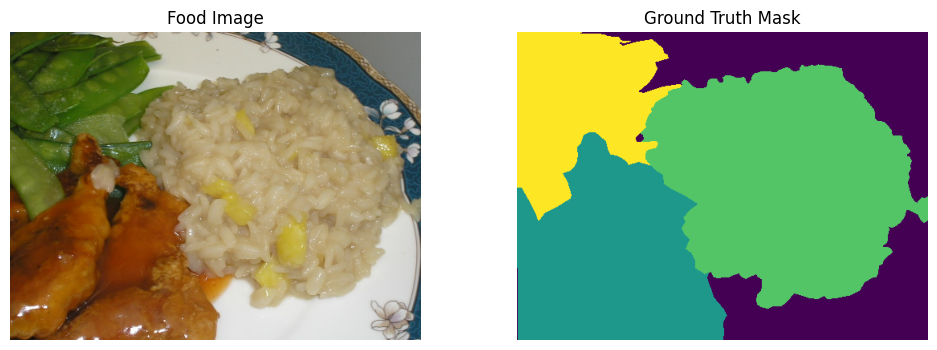

Unique class labels in this mask: [ 0 48 66 90]
Total classes in dataset: 104 (0=background, 1-103=food categories)


In [ ]:
# Sample image and ground truth mask
sample = train_ids[0]
base   = sample.split(".")[0]

image = Image.open(os.path.join(train_img_dir, base + ".jpg"))
mask  = Image.open(os.path.join(train_mask_dir, base + ".png"))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.imshow(image); plt.title("Food Image"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(mask);  plt.title("Ground Truth Mask"); plt.axis("off")
plt.show()

print("Unique class labels in this mask:", np.unique(np.array(mask)))
print("Total classes in dataset: 104 (0=background, 1-103=food categories)")

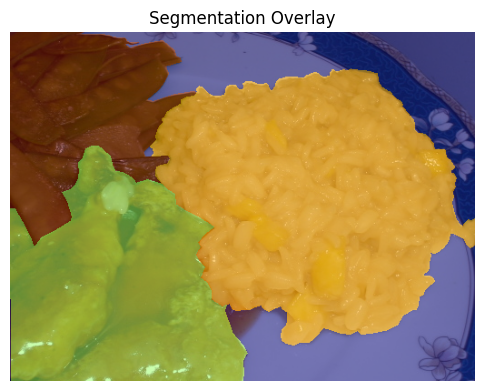

In [ ]:
# Overlay mask on image
image_np = np.array(image)
mask_np  = np.array(mask)

plt.figure(figsize=(6,6))
plt.imshow(image_np)
plt.imshow(mask_np, cmap="jet", alpha=0.5)
plt.title("Segmentation Overlay")
plt.axis("off")
plt.show()

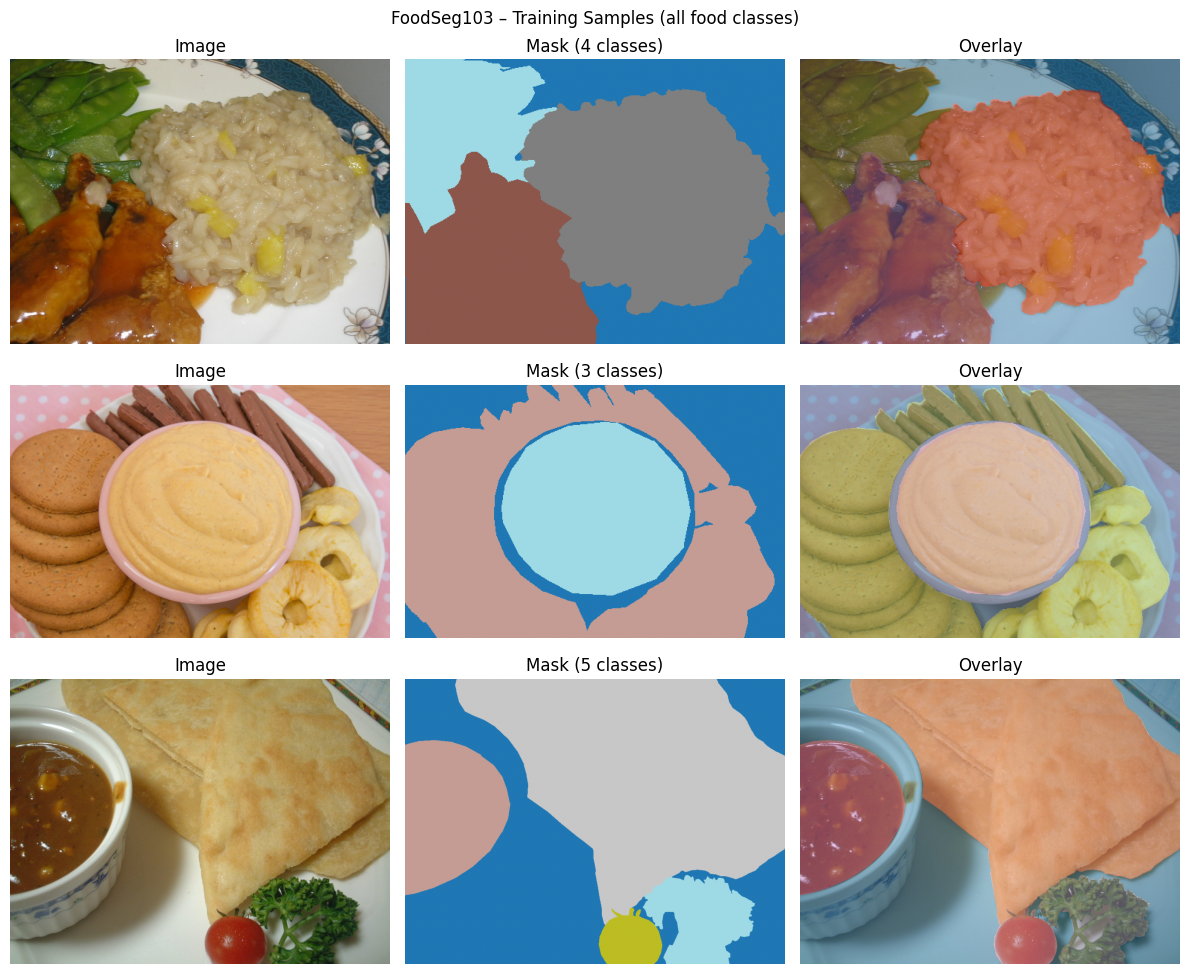

In [ ]:
# Show 3 training samples: image, ground truth, overlay
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
fig.suptitle("FoodSeg103 – Training Samples (all food classes)", fontsize=12)

for row, idx in enumerate([0, 10, 50]):
    b   = train_ids[idx].split(".")[0]
    img = np.array(Image.open(os.path.join(train_img_dir,  b + ".jpg")).convert("RGB"))
    msk = np.array(Image.open(os.path.join(train_mask_dir, b + ".png")))

    axes[row, 0].imshow(img); axes[row, 0].set_title("Image"); axes[row, 0].axis("off")
    axes[row, 1].imshow(msk, cmap="tab20"); axes[row, 1].set_title(f"Mask ({len(np.unique(msk))} classes)"); axes[row, 1].axis("off")

    col_msk = plt.cm.tab20(msk % 20)[:, :, :3]
    blend   = (0.6 * img/255 + 0.4 * col_msk).clip(0,1)
    axes[row, 2].imshow(blend); axes[row, 2].set_title("Overlay"); axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

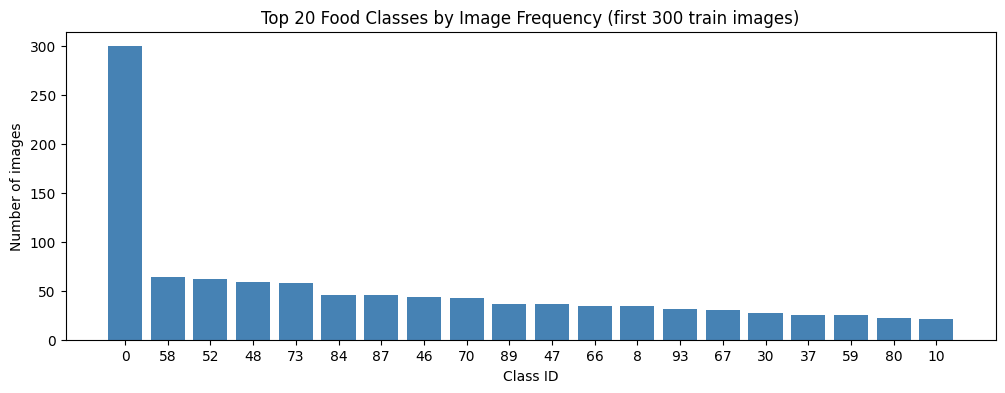

Classes present: 78 out of 103 food categories
Background (0) appears in: 300 images


In [ ]:
# Class distribution — how many images contain each food class
class_counts = np.zeros(NUM_CLASSES, dtype=int)

for img_id in train_ids[:300]:
    b  = img_id.split(".")[0]
    mp = os.path.join(train_mask_dir, b + ".png")
    if os.path.exists(mp):
        m = np.array(Image.open(mp))
        for cls in np.unique(m):
            if cls < NUM_CLASSES:
                class_counts[cls] += 1

# Show top 20 most common food classes
top20_idx = np.argsort(class_counts)[-20:][::-1]
top20_cnt = class_counts[top20_idx]

plt.figure(figsize=(12,4))
plt.bar([str(i) for i in top20_idx], top20_cnt, color="steelblue")
plt.title("Top 20 Food Classes by Image Frequency (first 300 train images)")
plt.xlabel("Class ID"); plt.ylabel("Number of images")
plt.show()

print("Classes present:", np.sum(class_counts > 0), "out of 103 food categories")
print("Background (0) appears in:", class_counts[0], "images")

## 8. Data Augmentation
Applied only during enhanced model training. Each transformation is applied to both image and mask together so labels stay aligned.
Helps the model generalise better by seeing varied orientations, scales, and lighting conditions.

In [ ]:
def augment(image, mask):
    # Random horizontal flip
    if random.random() > 0.5:
        image = cv2.flip(image, 1)
        mask  = cv2.flip(mask,  1)

    # Random 90-degree rotation
    if random.random() > 0.5:
        k     = random.choice([1, 2, 3])
        image = np.rot90(image, k).copy()
        mask  = np.rot90(mask,  k).copy()

    # Random zoom (crop then resize)
    if random.random() > 0.5:
        h, w   = image.shape[:2]
        scale  = random.uniform(0.75, 0.95)
        ch, cw = int(h * scale), int(w * scale)
        y = random.randint(0, h - ch)
        x = random.randint(0, w - cw)
        image = cv2.resize(image[y:y+ch, x:x+cw], (w, h))
        mask  = cv2.resize(mask[y:y+ch, x:x+cw],  (w, h), interpolation=cv2.INTER_NEAREST)

    # Colour jitter (image only)
    if random.random() > 0.5:
        alpha = random.uniform(0.8, 1.2)
        beta  = random.randint(-20, 20)
        image = np.clip(alpha * image + beta, 0, 255).astype(np.uint8)
    # vertical flip
    if random.random() > 0.5:
      image = cv2.flip(image, 0)
      mask  = cv2.flip(mask,  0)

    return image, mask

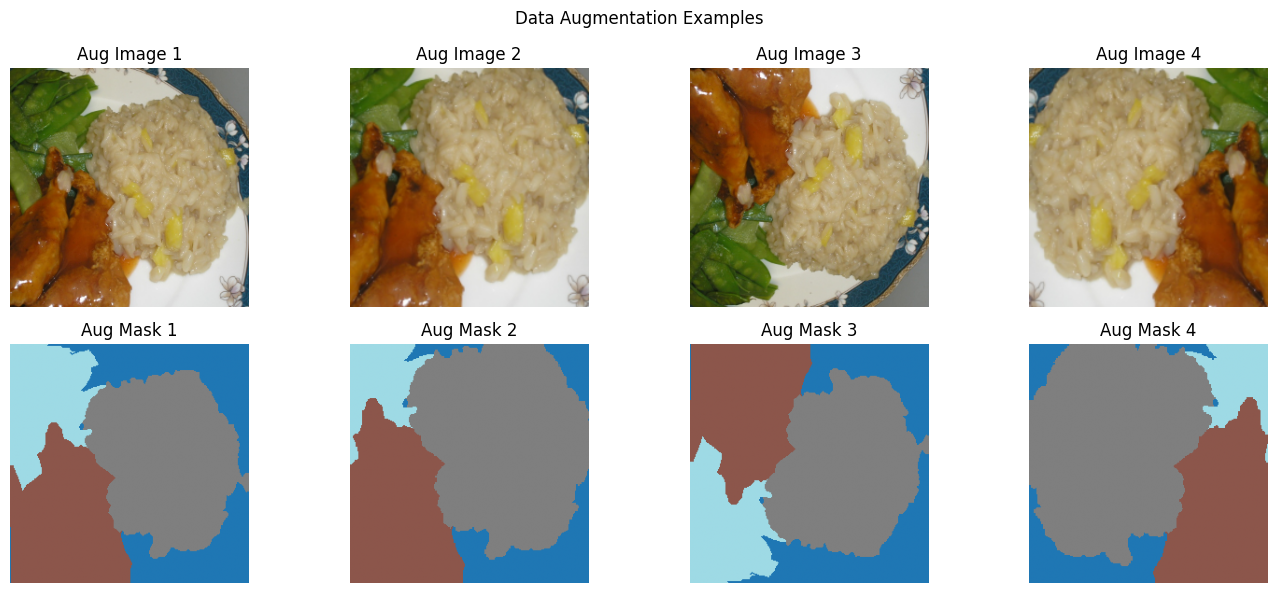

In [ ]:
# Visualise augmentation examples
b       = train_ids[0].split(".")[0]
img_raw = cv2.resize(np.array(Image.open(os.path.join(train_img_dir,  b+".jpg")).convert("RGB")), (IMG_SIZE,IMG_SIZE))
msk_raw = cv2.resize(np.array(Image.open(os.path.join(train_mask_dir, b+".png"))),                (IMG_SIZE,IMG_SIZE), interpolation=cv2.INTER_NEAREST)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle("Data Augmentation Examples", fontsize=12)
for col in range(4):
    ai, am = augment(img_raw.copy(), msk_raw.copy())
    axes[0,col].imshow(ai); axes[0,col].set_title(f"Aug Image {col+1}"); axes[0,col].axis("off")
    axes[1,col].imshow(am, cmap="tab20"); axes[1,col].set_title(f"Aug Mask {col+1}"); axes[1,col].axis("off")
plt.tight_layout(); plt.show()

## 9. Dataset & DataLoaders
Custom `FoodSegDataset` loads images and masks, resizes to `IMG_SIZE`, and optionally applies augmentation.
Mask values 0–103 are used directly as class indices — no remapping needed.

In [ ]:
class FoodSegDataset(Dataset):

    def __init__(self, ids, img_dir, mask_dir, use_augment=False):

        self.ids         = ids
        self.img_dir     = img_dir
        self.mask_dir    = mask_dir
        self.use_augment = use_augment

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):

        img_id = self.ids[idx].split(".")[0]

        img_path  = os.path.join(self.img_dir,  img_id + ".jpg")
        mask_path = os.path.join(self.mask_dir, img_id + ".png")

        image = np.array(Image.open(img_path).convert("RGB"))
        mask  = np.array(Image.open(mask_path))

        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        mask  = cv2.resize(mask,  (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

        if self.use_augment:
            image, mask = augment(image, mask)

        # Mask values 0-103 are already class indices — use directly
        mask = np.clip(mask, 0, 103).astype(np.int64)

        image = torch.tensor(image).permute(2, 0, 1).float() / 255
        mask  = torch.tensor(mask).long()

        return image, mask

In [ ]:
train_dataset_full = FoodSegDataset(train_ids, train_img_dir, train_mask_dir)
test_dataset       = FoodSegDataset(test_ids,  test_img_dir,  test_mask_dir)

train_size = int(0.8 * len(train_dataset_full))
val_size   = len(train_dataset_full) - train_size

train_dataset, val_dataset = random_split(train_dataset_full, [train_size, val_size])

print("Train:", len(train_dataset))
print("Val:  ", len(val_dataset))
print("Test: ", len(test_dataset))

Train: 3986
Val:   997
Test:  2135


In [ ]:
# pin_memory and num_workers for full GPU utilisation
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          num_workers=NUM_WORKERS, pin_memory=True)

print("Batches – Train:", len(train_loader), "| Val:", len(val_loader), "| Test:", len(test_loader))

Batches – Train: 125 | Val: 32 | Test: 67


## 10. Evaluation Metrics
**mIoU** (mean Intersection over Union) is the primary metric — it evaluates each class equally regardless of pixel count, making it suitable for imbalanced datasets like FoodSeg103 where background dominates.
**Pixel accuracy** is also tracked but less meaningful here due to class imbalance.

In [ ]:
def compute_iou(preds, masks, num_classes):

    ious = []

    preds = preds.view(-1)
    masks = masks.view(-1)

    for cls in range(num_classes):

        pred_inds   = preds == cls
        target_inds = masks == cls

        intersection = (pred_inds & target_inds).sum().item()
        union        = (pred_inds | target_inds).sum().item()

        if union == 0:
            ious.append(np.nan)
        else:
            ious.append(intersection / union)

    return np.nanmean(ious)


def compute_accuracy(preds, masks):

    correct = (preds == masks).float().sum()
    total   = torch.numel(masks)

    return (correct / total).item()

## 11. Model Overview

| | Baseline | Enhanced |
|---|---|---|
| Architecture | U-Net + ResNet34 | U-Net + ResNet34 |
| Encoder weights | None (random init) | ImageNet (transfer learning) |
| Classes | 104 | 104 |
| Epochs | 10 | 45 |
| Learning rate | 1e-4 fixed | 1e-4 with ReduceLROnPlateau |
| Loss | CrossEntropyLoss | CrossEntropyLoss (background weight=0.1) |
| Data augmentation | No | Yes |
| Best-model checkpoint | No | Yes |

Architecture is the same for both — this isolates the effect of training strategy and pre-training on performance.

---
## 12. Baseline Model
U-Net + ResNet34 trained from random initialisation. No augmentation, no scheduler, fixed LR.
This is the starting point — a reasonable architecture but without any training enhancements.

In [ ]:
EPOCHS_BASELINE = 10

baseline_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,       # random initialisation — no pre-training
    classes=NUM_CLASSES,
    activation=None
)

baseline_model = baseline_model.to(DEVICE)
print("Baseline model ready")

Baseline model ready


In [ ]:
criterion_b = nn.CrossEntropyLoss()

optimizer_b = optim.Adam(
    baseline_model.parameters(),
    lr=LR
)

In [ ]:
baseline_train_losses = []
baseline_val_losses   = []
baseline_train_accs   = []
baseline_val_accs     = []
baseline_val_ious     = []

baseline_model_path = os.path.join(MODEL_DIR, "baseline_model.pth")

for epoch in range(EPOCHS_BASELINE):

    # Train
    baseline_model.train()
    train_loss = 0
    train_accs = []

    for images, masks in train_loader:
        images = images.to(DEVICE, non_blocking=True)
        masks  = masks.to(DEVICE,  non_blocking=True)

        outputs = baseline_model(images)
        loss    = criterion_b(outputs, masks)

        optimizer_b.zero_grad()
        loss.backward()
        optimizer_b.step()

        train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        train_accs.append(compute_accuracy(preds, masks))

    train_loss /= len(train_loader)
    train_acc   = np.mean(train_accs)

    # Validate
    baseline_model.eval()
    val_loss = 0
    val_accs = []
    val_ious = []

    with torch.no_grad():
        for images, masks in val_loader:
            images  = images.to(DEVICE, non_blocking=True)
            masks   = masks.to(DEVICE,  non_blocking=True)
            outputs = baseline_model(images)
            val_loss += criterion_b(outputs, masks).item()
            preds = torch.argmax(outputs, dim=1)
            val_accs.append(compute_accuracy(preds, masks))
            val_ious.append(compute_iou(preds.cpu(), masks.cpu(), NUM_CLASSES))

    val_loss /= len(val_loader)
    val_acc   = np.mean(val_accs)
    val_iou   = np.mean(val_ious)

    baseline_train_losses.append(train_loss)
    baseline_val_losses.append(val_loss)
    baseline_train_accs.append(train_acc)
    baseline_val_accs.append(val_acc)
    baseline_val_ious.append(val_iou)

    print(f"Epoch {epoch+1}/{EPOCHS_BASELINE} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val mIoU: {val_iou:.4f}")

torch.save(baseline_model.state_dict(), baseline_model_path)
print("\nBaseline training complete | Model saved")

Epoch 1/10 | Train Loss: 3.9676 | Val Loss: 3.3113 | Train Acc: 0.3063 | Val Acc: 0.4569 | Val mIoU: 0.0215
Epoch 2/10 | Train Loss: 2.8952 | Val Loss: 2.5992 | Train Acc: 0.4826 | Val Acc: 0.4956 | Val mIoU: 0.0284
Epoch 3/10 | Train Loss: 2.4474 | Val Loss: 2.3481 | Train Acc: 0.5041 | Val Acc: 0.5028 | Val mIoU: 0.0282
Epoch 4/10 | Train Loss: 2.2237 | Val Loss: 2.2074 | Train Acc: 0.5147 | Val Acc: 0.5080 | Val mIoU: 0.0305
Epoch 5/10 | Train Loss: 2.0891 | Val Loss: 2.1382 | Train Acc: 0.5238 | Val Acc: 0.5059 | Val mIoU: 0.0344
Epoch 6/10 | Train Loss: 2.0048 | Val Loss: 2.0878 | Train Acc: 0.5335 | Val Acc: 0.5109 | Val mIoU: 0.0392
Epoch 7/10 | Train Loss: 1.9375 | Val Loss: 2.0043 | Train Acc: 0.5427 | Val Acc: 0.5263 | Val mIoU: 0.0429
Epoch 8/10 | Train Loss: 1.8742 | Val Loss: 2.0490 | Train Acc: 0.5537 | Val Acc: 0.5313 | Val mIoU: 0.0473
Epoch 9/10 | Train Loss: 1.8112 | Val Loss: 2.0132 | Train Acc: 0.5661 | Val Acc: 0.5108 | Val mIoU: 0.0449
Epoch 10/10 | Train Loss: 1.

### 12.1 Baseline – Test Set Evaluation
Loading the saved baseline model and running it on the held-out test set.

In [ ]:
baseline_model_path = os.path.join(MODEL_DIR, "baseline_model.pth")
baseline_model.load_state_dict(torch.load(baseline_model_path, map_location=DEVICE))
baseline_model.eval()
print("Loaded baseline model")

Loaded baseline model


In [ ]:
b_ious = []
b_accs = []

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(DEVICE, non_blocking=True)
        masks  = masks.to(DEVICE,  non_blocking=True)

        outputs = baseline_model(images)
        preds   = torch.argmax(outputs, dim=1)

        b_ious.append(compute_iou(preds.cpu(), masks.cpu(), NUM_CLASSES))
        b_accs.append(compute_accuracy(preds, masks))

print("Baseline Test Accuracy:", round(np.mean(b_accs), 4))
print("Baseline Test Mean IoU:", round(np.mean(b_ious), 4))

Baseline Test Accuracy: 0.5412
Baseline Test Mean IoU: 0.0569


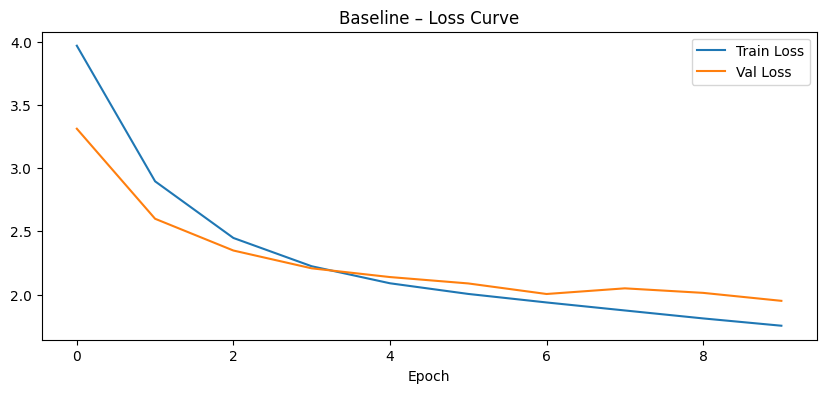

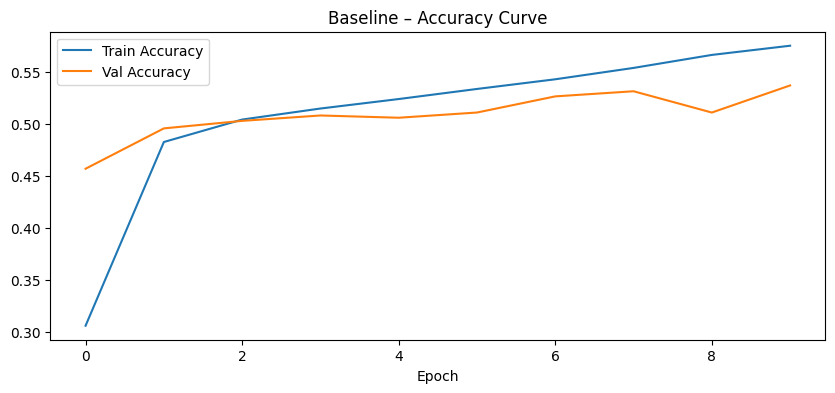

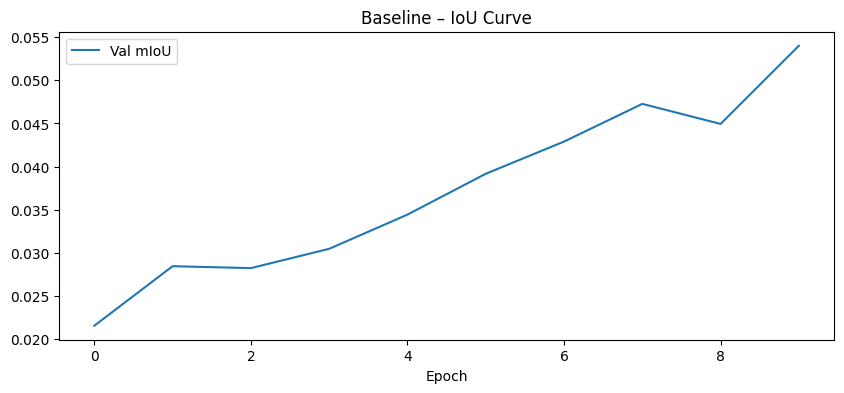

In [ ]:
# Baseline training curves
plt.figure(figsize=(10,4))
plt.plot(baseline_train_losses, label="Train Loss")
plt.plot(baseline_val_losses,   label="Val Loss")
plt.legend(); plt.title("Baseline – Loss Curve"); plt.xlabel("Epoch"); plt.show()

plt.figure(figsize=(10,4))
plt.plot(baseline_train_accs, label="Train Accuracy")
plt.plot(baseline_val_accs,   label="Val Accuracy")
plt.legend(); plt.title("Baseline – Accuracy Curve"); plt.xlabel("Epoch"); plt.show()

plt.figure(figsize=(10,4))
plt.plot(baseline_val_ious, label="Val mIoU")
plt.legend(); plt.title("Baseline – IoU Curve"); plt.xlabel("Epoch"); plt.show()

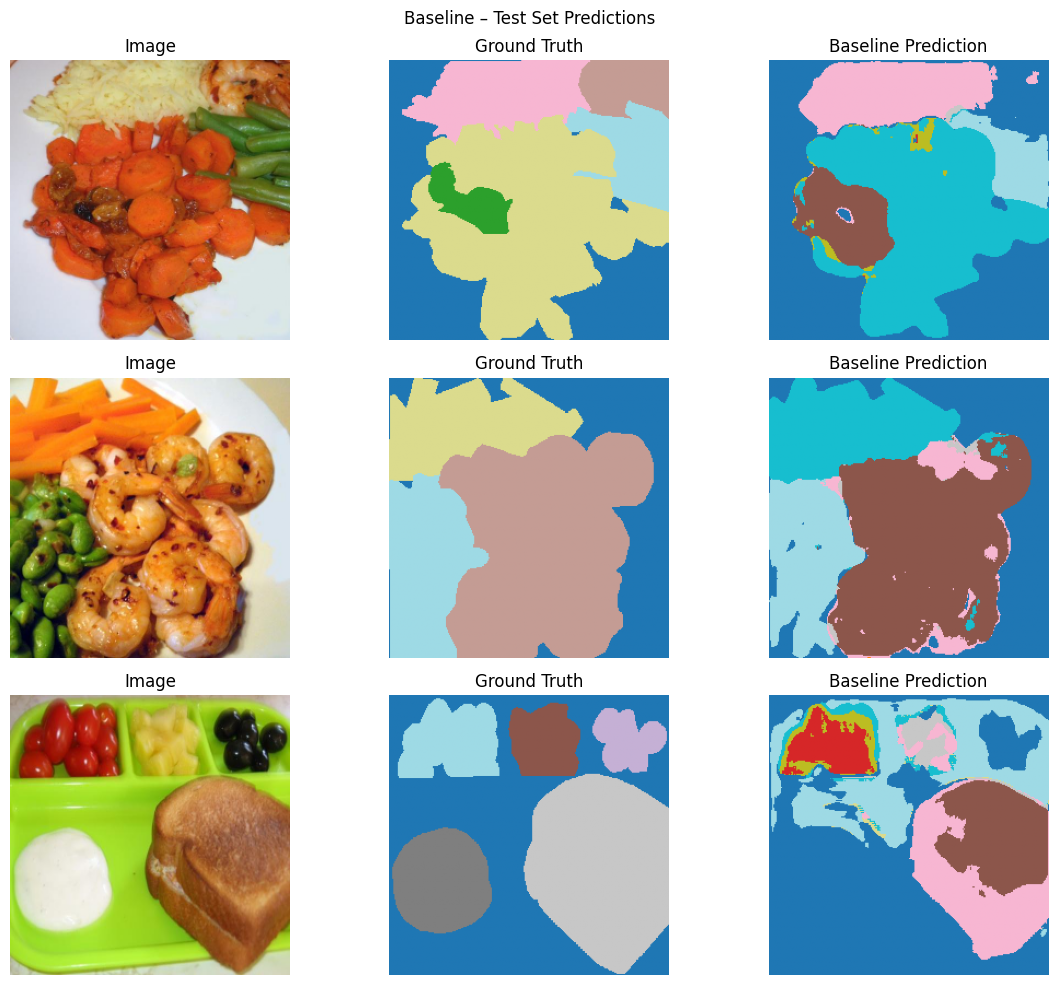

In [ ]:
# Baseline visual prediction on 3 test samples
baseline_model.eval()

images, masks = next(iter(test_loader))
images = images.to(DEVICE)

with torch.no_grad():
    preds = baseline_model(images)

pred = torch.argmax(preds, dim=1).cpu()

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
fig.suptitle("Baseline – Test Set Predictions", fontsize=12)

for row in range(3):
    axes[row,0].imshow(images[row].permute(1,2,0).cpu()); axes[row,0].set_title("Image"); axes[row,0].axis("off")
    axes[row,1].imshow(masks[row], cmap="tab20"); axes[row,1].set_title("Ground Truth"); axes[row,1].axis("off")
    axes[row,2].imshow(pred[row],  cmap="tab20"); axes[row,2].set_title("Baseline Prediction"); axes[row,2].axis("off")

plt.tight_layout(); plt.show()

---
## 13. Enhanced Model
Same U-Net + ResNet34 architecture, but with ImageNet pre-trained weights.
Key improvements over baseline:
- **ImageNet pre-training** — encoder already knows edges, textures, and shapes
- **Weighted loss** — background class weight reduced to 0.1 so model focuses on food regions
- **ReduceLROnPlateau** — learning rate halves when validation loss stops improving
- **Data augmentation** — flip, rotate, zoom, colour jitter
- **Best-model checkpoint** — saves only when validation mIoU improves

In [ ]:
# Augmented train dataset for enhanced model
aug_train_dataset = FoodSegDataset(
    train_ids[:train_size],
    train_img_dir,
    train_mask_dir,
    use_augment=True
)
aug_train_loader = DataLoader(aug_train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True)

In [ ]:
EPOCHS = 45

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",    # ImageNet transfer learning
    classes=NUM_CLASSES,
    activation=None
)

model = model.to(DEVICE)
print("Enhanced model ready")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Enhanced model ready


In [ ]:
weights = torch.ones(NUM_CLASSES).to(DEVICE)
weights[0] = 0.1   # background gets 10x less weight
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)

In [ ]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.5,
)

In [ ]:
def train_one_epoch(model, train_loader, optimizer, criterion):

    model.train()

    train_loss = 0
    train_accs = []
    train_ious = []

    for images, masks in train_loader:

        images = images.to(DEVICE, non_blocking=True)
        masks  = masks.to(DEVICE,  non_blocking=True)

        outputs = model(images)
        loss    = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        preds = torch.argmax(outputs, dim=1)
        train_accs.append(compute_accuracy(preds, masks))
        train_ious.append(compute_iou(preds.cpu(), masks.cpu(), NUM_CLASSES))
        train_loss += loss.item()

    train_loss    /= len(train_loader)
    train_accuracy = np.mean(train_accs)
    train_iou      = np.mean(train_ious)

    return train_loss, train_accuracy, train_iou

In [ ]:
def validate(model, val_loader, criterion):

    model.eval()

    val_loss = 0
    val_accs = []
    ious     = []

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(DEVICE, non_blocking=True)
            masks  = masks.to(DEVICE,  non_blocking=True)

            outputs = model(images)
            loss    = criterion(outputs, masks)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            val_accs.append(compute_accuracy(preds, masks))
            ious.append(compute_iou(preds.cpu(), masks.cpu(), NUM_CLASSES))

    val_loss     /= len(val_loader)
    val_accuracy  = np.mean(val_accs)
    mean_iou      = np.mean(ious)

    return val_loss, val_accuracy, mean_iou

In [ ]:
best_miou = 0

train_losses     = []
val_losses       = []
val_ious         = []
train_ious       = []
train_accuracies = []
val_accuracies   = []

model_path = os.path.join(MODEL_DIR, "foodseg_best_miou_model.pth")

for epoch in range(EPOCHS):

    train_loss, train_accuracy, train_iou = train_one_epoch(
        model, aug_train_loader, optimizer, criterion
    )

    val_loss, val_accuracy, mean_iou = validate(
        model, val_loader, criterion
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)
    val_ious.append(mean_iou)
    train_ious.append(train_iou)

    scheduler.step(val_loss)

    if mean_iou > best_miou:
        best_miou = mean_iou
        torch.save(model.state_dict(), model_path)
        saved = " --> best model saved"
    else:
        saved = ""

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f} | Train mIoU: {train_iou:.4f} | Val mIoU: {mean_iou:.4f}{saved}")

print("\nEnhanced training complete")
print("Best Val mIoU:", round(best_miou, 4))

Epoch 1/45 | Train Loss: 4.0908 | Val Loss: 3.6580 | Train Acc: 0.0889 | Val Acc: 0.1265 | Train mIoU: 0.0133 | Val mIoU: 0.0248 --> best model saved
Epoch 2/45 | Train Loss: 3.3298 | Val Loss: 3.1391 | Train Acc: 0.2208 | Val Acc: 0.4032 | Train mIoU: 0.0412 | Val mIoU: 0.0599 --> best model saved
Epoch 3/45 | Train Loss: 2.9636 | Val Loss: 2.8785 | Train Acc: 0.4600 | Val Acc: 0.5270 | Train mIoU: 0.0787 | Val mIoU: 0.0847 --> best model saved
Epoch 4/45 | Train Loss: 2.7152 | Val Loss: 2.6846 | Train Acc: 0.5172 | Val Acc: 0.5575 | Train mIoU: 0.0994 | Val mIoU: 0.0987 --> best model saved
Epoch 5/45 | Train Loss: 2.5445 | Val Loss: 2.5190 | Train Acc: 0.5371 | Val Acc: 0.5898 | Train mIoU: 0.1099 | Val mIoU: 0.1093 --> best model saved
Epoch 6/45 | Train Loss: 2.3889 | Val Loss: 2.3957 | Train Acc: 0.5617 | Val Acc: 0.5958 | Train mIoU: 0.1228 | Val mIoU: 0.1224 --> best model saved
Epoch 7/45 | Train Loss: 2.2777 | Val Loss: 2.2970 | Train Acc: 0.5779 | Val Acc: 0.6043 | Train mIo

### 13.1 Enhanced Model – Test Set Evaluation
Loading the best checkpoint and evaluating on the test set.

In [ ]:
model_path = os.path.join(MODEL_DIR, "foodseg_best_miou_model.pth")
model.load_state_dict(torch.load(model_path, map_location=DEVICE))
model.eval()
print("Loaded best enhanced model")

Loaded best enhanced model


In [ ]:
test_ious = []
test_accs = []

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(DEVICE, non_blocking=True)
        masks  = masks.to(DEVICE,  non_blocking=True)

        outputs = model(images)
        preds   = torch.argmax(outputs, dim=1)

        test_ious.append(compute_iou(preds.cpu(), masks.cpu(), NUM_CLASSES))
        test_accs.append(compute_accuracy(preds, masks))

test_miou     = np.mean(test_ious)
test_accuracy = np.mean(test_accs)

print("Test Accuracy:", round(test_accuracy, 4))
print("Test Mean IoU:", round(test_miou, 4))

Test Accuracy: 0.6848
Test Mean IoU: 0.2113


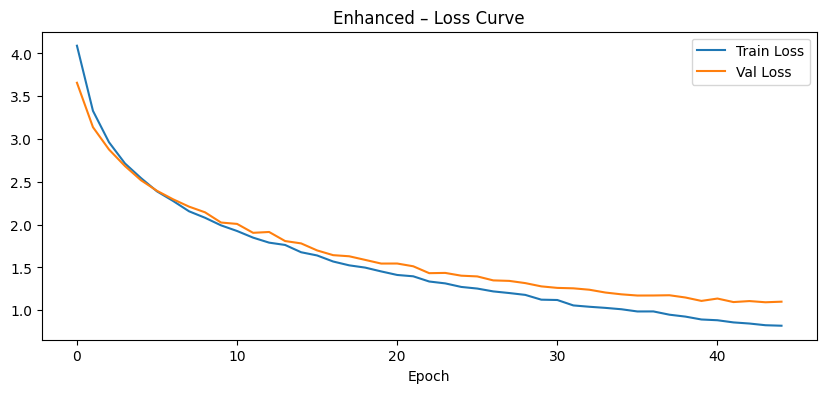

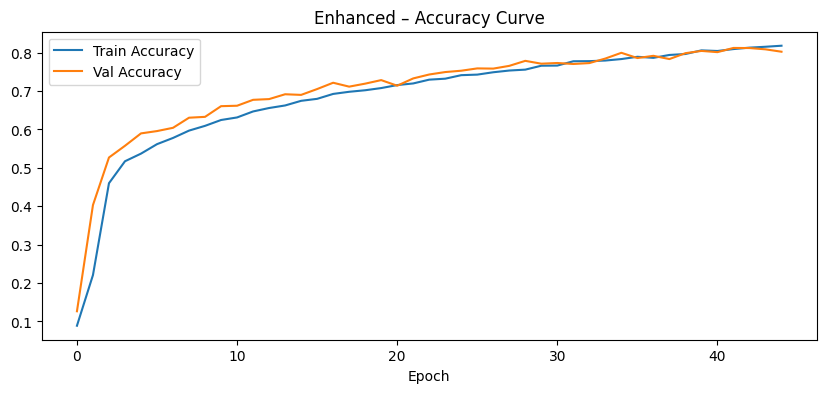

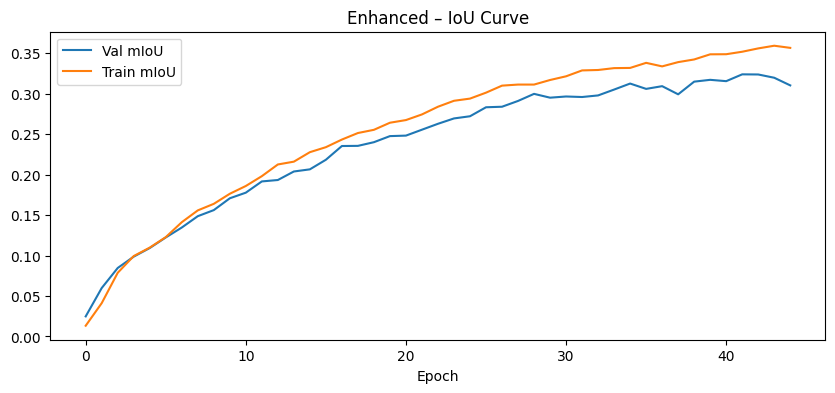

In [ ]:
# Enhanced training curves
plt.figure(figsize=(10,4))
plt.plot(train_losses, label="Train Loss"); plt.plot(val_losses, label="Val Loss")
plt.legend(); plt.title("Enhanced – Loss Curve"); plt.xlabel("Epoch"); plt.show()

plt.figure(figsize=(10,4))
plt.plot(train_accuracies, label="Train Accuracy"); plt.plot(val_accuracies, label="Val Accuracy")
plt.legend(); plt.title("Enhanced – Accuracy Curve"); plt.xlabel("Epoch"); plt.show()

plt.figure(figsize=(10,4))
plt.plot(val_ious, label="Val mIoU"); plt.plot(train_ious, label="Train mIoU")
plt.legend(); plt.title("Enhanced – IoU Curve"); plt.xlabel("Epoch"); plt.show()

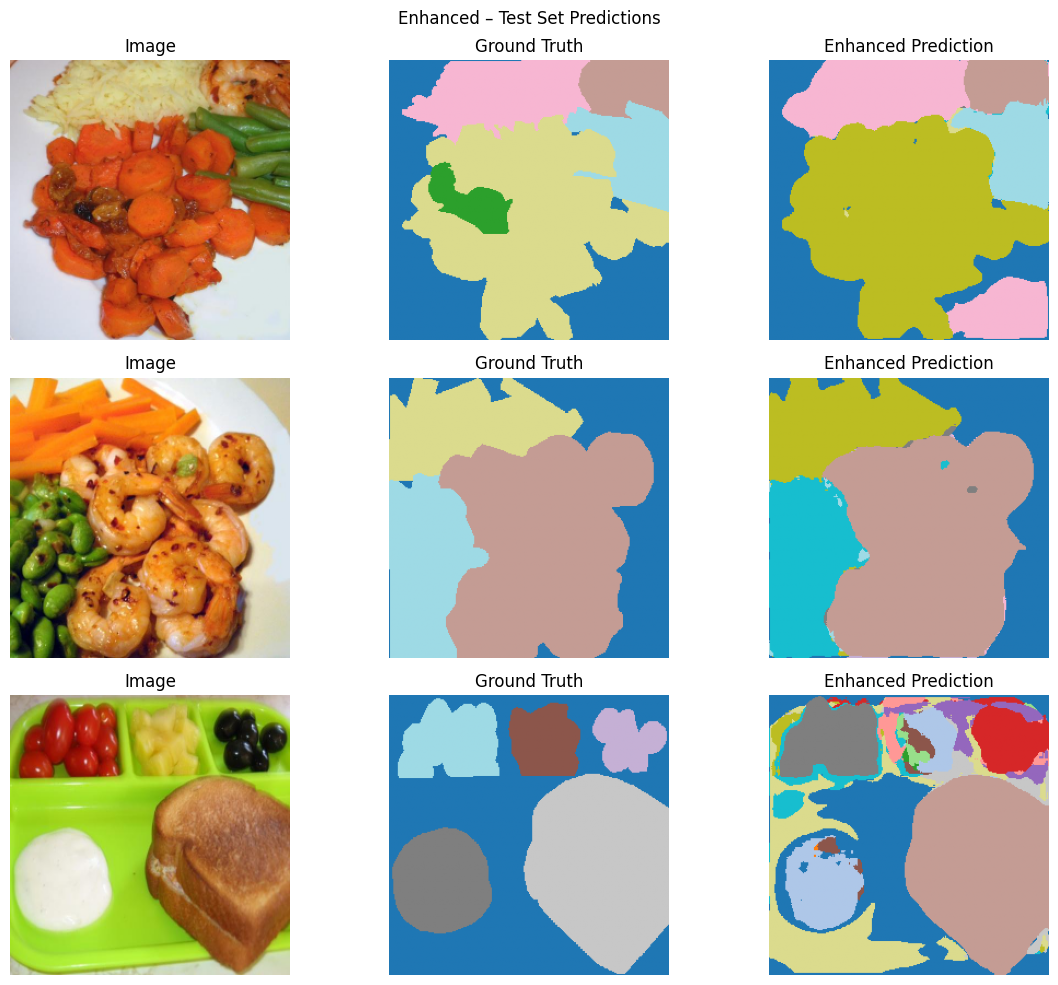

In [ ]:
# Enhanced visual predictions on 3 test samples
images, masks = next(iter(test_loader))
images = images.to(DEVICE)

with torch.no_grad():
    preds = model(images)

pred = torch.argmax(preds, dim=1).cpu()

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
fig.suptitle("Enhanced – Test Set Predictions", fontsize=12)

for row in range(3):
    axes[row,0].imshow(images[row].permute(1,2,0).cpu()); axes[row,0].set_title("Image"); axes[row,0].axis("off")
    axes[row,1].imshow(masks[row], cmap="tab20"); axes[row,1].set_title("Ground Truth"); axes[row,1].axis("off")
    axes[row,2].imshow(pred[row],  cmap="tab20"); axes[row,2].set_title("Enhanced Prediction"); axes[row,2].axis("off")

plt.tight_layout(); plt.show()

---
## 14. Results Comparison
Side-by-side comparison of both models on the test set.

Model                          | Accuracy | mIoU
----------------------------------------------------
Baseline (no pre-training)     | 0.5412   | 0.0569
Enhanced (ImageNet + aug)      | 0.6848   | 0.2113


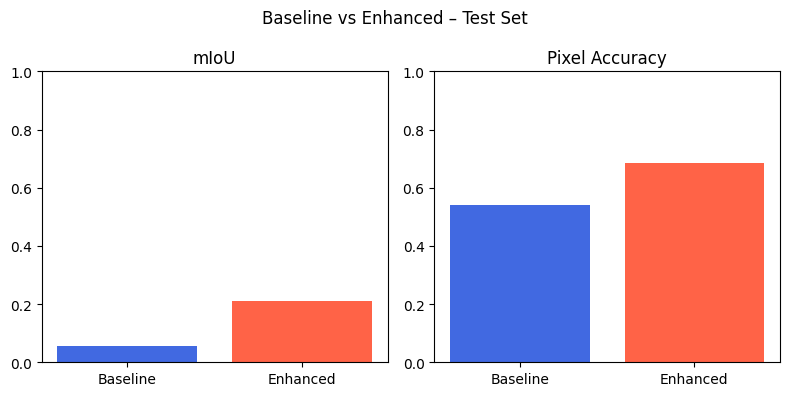

In [ ]:
print("Model                          | Accuracy | mIoU")
print("-" * 52)
print(f"Baseline (no pre-training)     | {np.mean(b_accs):.4f}   | {np.mean(b_ious):.4f}")
print(f"Enhanced (ImageNet + aug)      | {test_accuracy:.4f}   | {test_miou:.4f}")

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.bar(["Baseline", "Enhanced"], [np.mean(b_ious), test_miou], color=["royalblue","tomato"])
plt.title("mIoU"); plt.ylim(0,1)

plt.subplot(1,2,2)
plt.bar(["Baseline", "Enhanced"], [np.mean(b_accs), test_accuracy], color=["royalblue","tomato"])
plt.title("Pixel Accuracy"); plt.ylim(0,1)

plt.suptitle("Baseline vs Enhanced – Test Set"); plt.tight_layout(); plt.show()

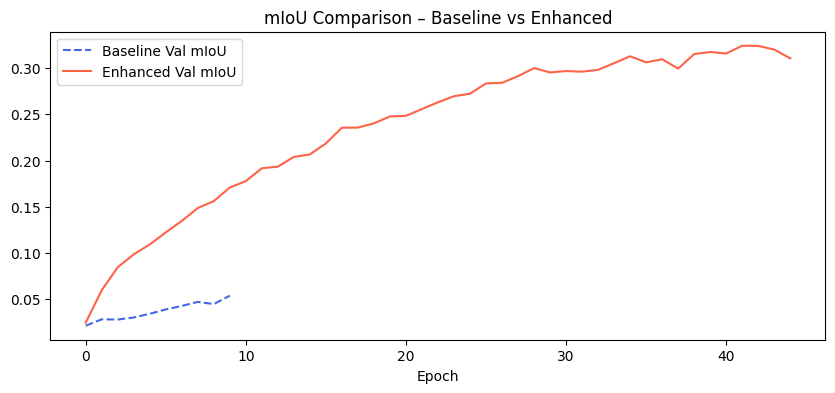

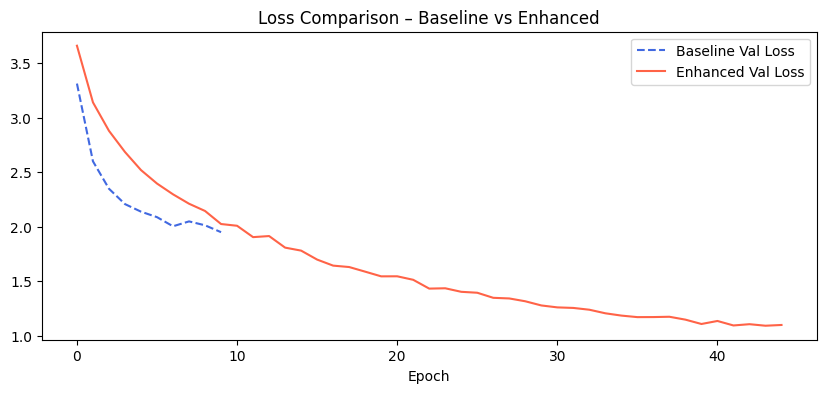

In [ ]:
# Combined training curves comparison
plt.figure(figsize=(10,4))
plt.plot(baseline_val_ious,  label="Baseline Val mIoU",  linestyle="--", color="royalblue")
plt.plot(val_ious,           label="Enhanced Val mIoU",  color="tomato")
plt.legend(); plt.title("mIoU Comparison – Baseline vs Enhanced"); plt.xlabel("Epoch"); plt.show()

plt.figure(figsize=(10,4))
plt.plot(baseline_val_losses, label="Baseline Val Loss", linestyle="--", color="royalblue")
plt.plot(val_losses,          label="Enhanced Val Loss", color="tomato")
plt.legend(); plt.title("Loss Comparison – Baseline vs Enhanced"); plt.xlabel("Epoch"); plt.show()

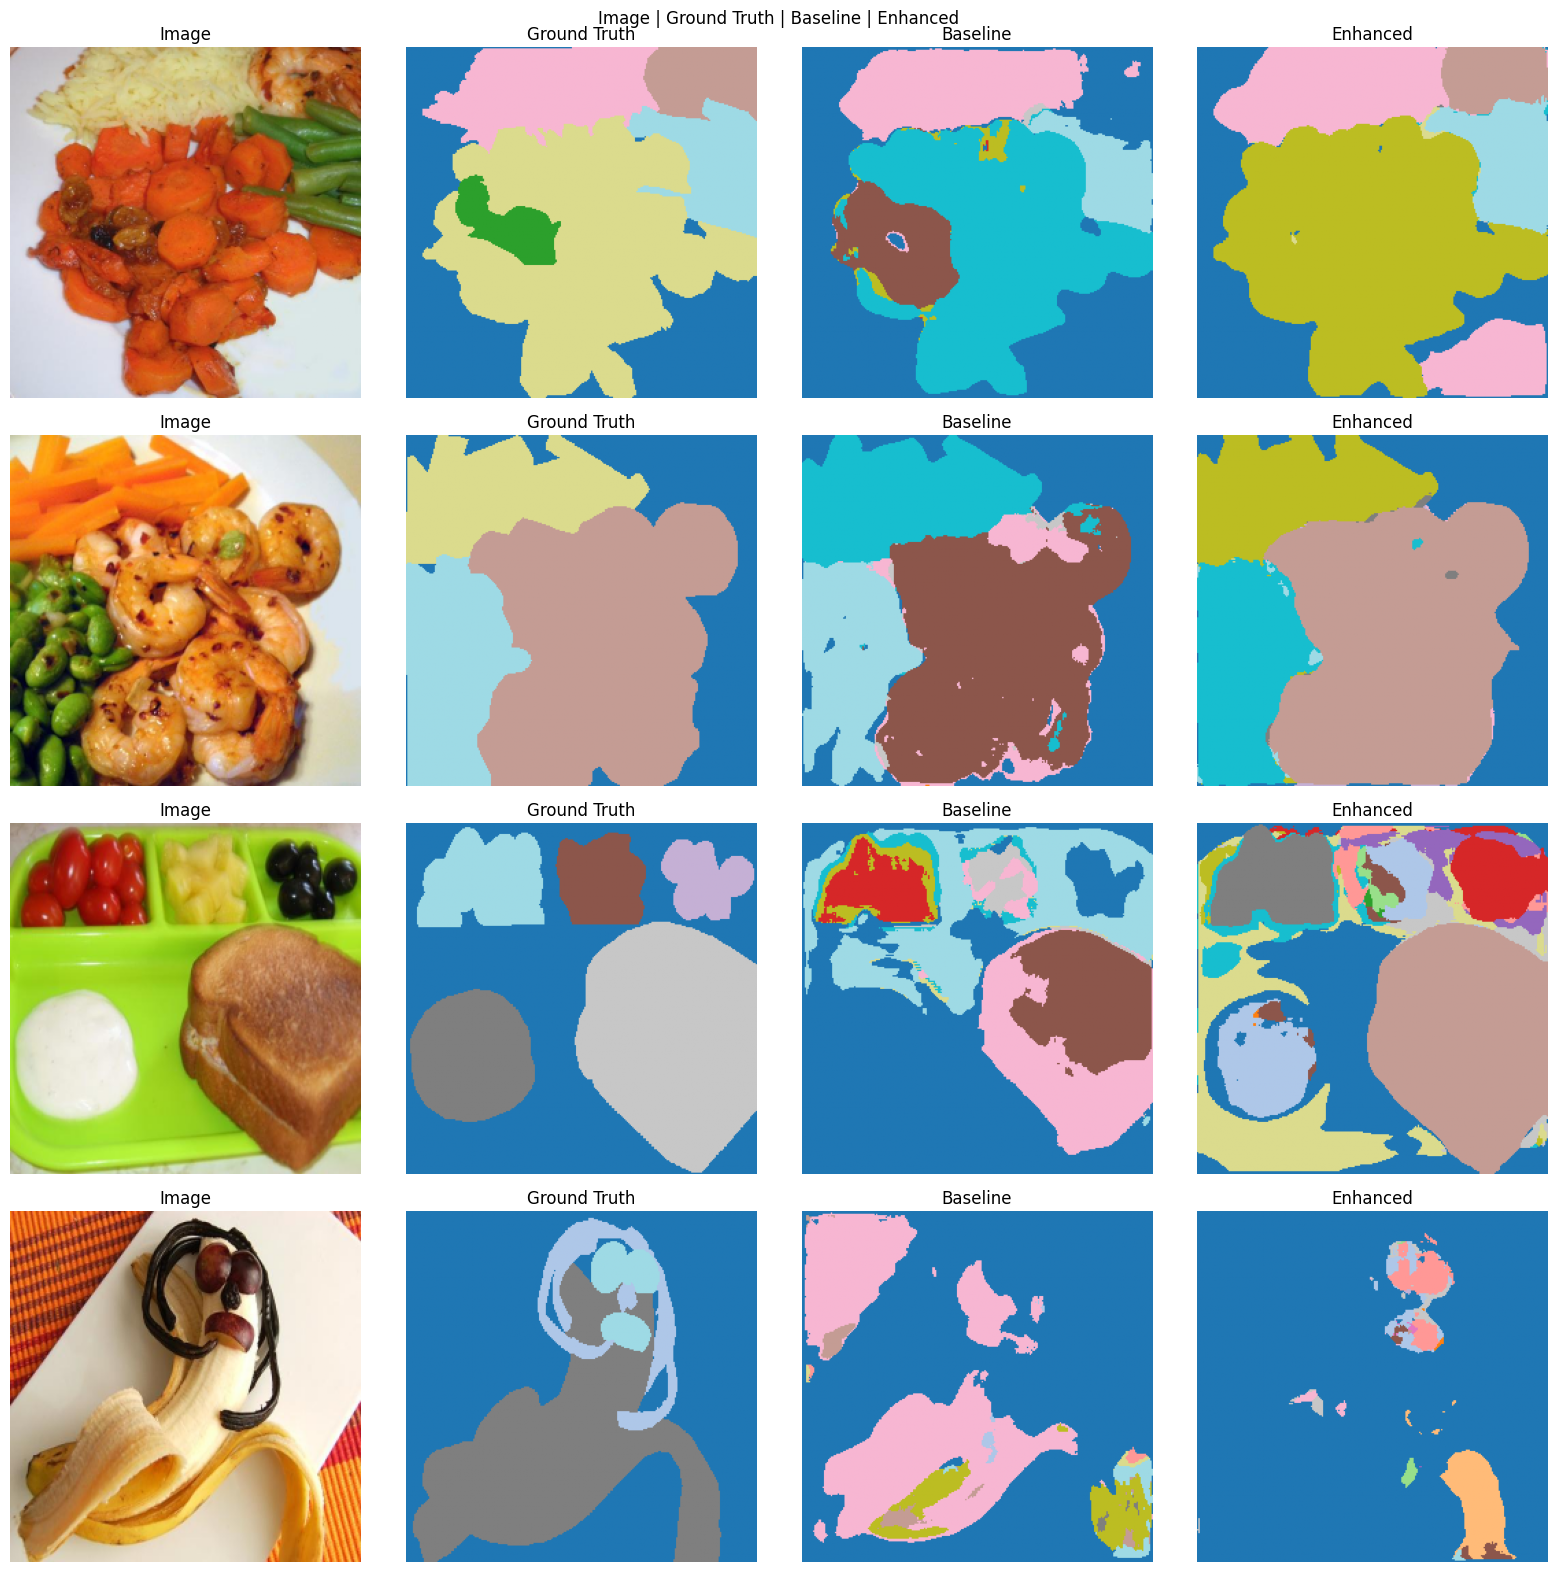

In [ ]:
# Side-by-side: image | ground truth | baseline | enhanced
baseline_model.eval()
model.eval()

images, masks = next(iter(test_loader))
images = images.to(DEVICE)

with torch.no_grad():
    b_preds = torch.argmax(baseline_model(images), dim=1).cpu()
    e_preds = torch.argmax(model(images),           dim=1).cpu()

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle("Image | Ground Truth | Baseline | Enhanced", fontsize=12)

for i in range(4):
    axes[i,0].imshow(images[i].permute(1,2,0).cpu()); axes[i,0].set_title("Image"); axes[i,0].axis("off")
    axes[i,1].imshow(masks[i],    cmap="tab20"); axes[i,1].set_title("Ground Truth"); axes[i,1].axis("off")
    axes[i,2].imshow(b_preds[i],  cmap="tab20"); axes[i,2].set_title("Baseline"); axes[i,2].axis("off")
    axes[i,3].imshow(e_preds[i],  cmap="tab20"); axes[i,3].set_title("Enhanced"); axes[i,3].axis("off")

plt.tight_layout(); plt.show()

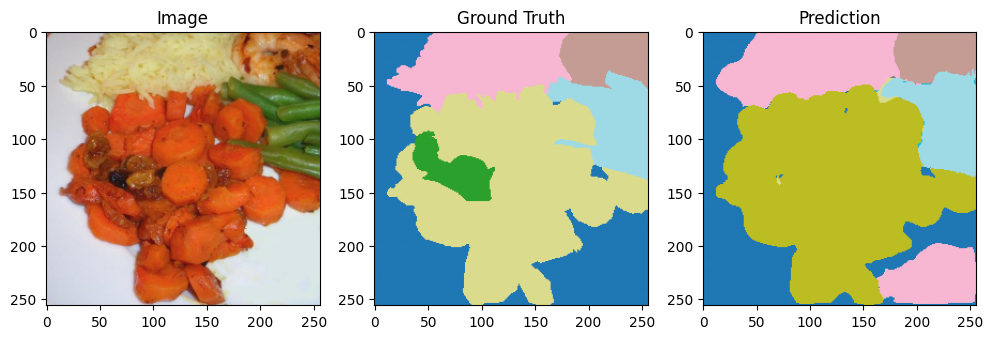

In [ ]:
# For use during demonstration session
images, masks = next(iter(test_loader))
images = images.to(DEVICE)

with torch.no_grad():
    preds = model(images)

pred = torch.argmax(preds, dim=1).cpu()

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(images[0].permute(1,2,0).cpu()); plt.title("Image")
plt.subplot(1,3,2); plt.imshow(masks[0], cmap="tab20"); plt.title("Ground Truth")
plt.subplot(1,3,3); plt.imshow(pred[0],  cmap="tab20"); plt.title("Prediction")
plt.show()

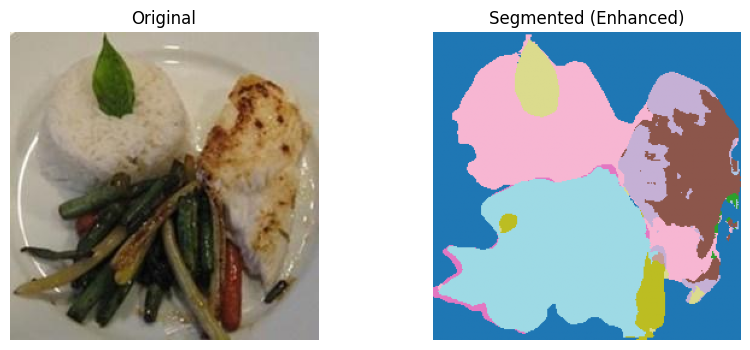

In [ ]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import cv2

# ---- IMAGE PATH ----
image_path = "/content/Task 1 Food Segmentation Dataset/FoodSeg103/Images/img_dir/test/00005609.jpg"

# ---- MODEL ----
model.eval()

# ---- LOAD IMAGE (SAME AS DATASET PIPELINE) ----
image = np.array(Image.open(image_path).convert("RGB"))
image_resized = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

input_tensor = torch.tensor(image_resized).permute(2, 0, 1).float() / 255
input_tensor = input_tensor.unsqueeze(0).to(DEVICE)

# ---- PREDICT ----
with torch.no_grad():
    output = model(input_tensor)
    pred_mask = torch.argmax(output, dim=1).squeeze().cpu().numpy()

# ---- SHOW ----
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(pred_mask, cmap="tab20")
plt.title("Segmented (Enhanced)")
plt.axis("off")

plt.show()